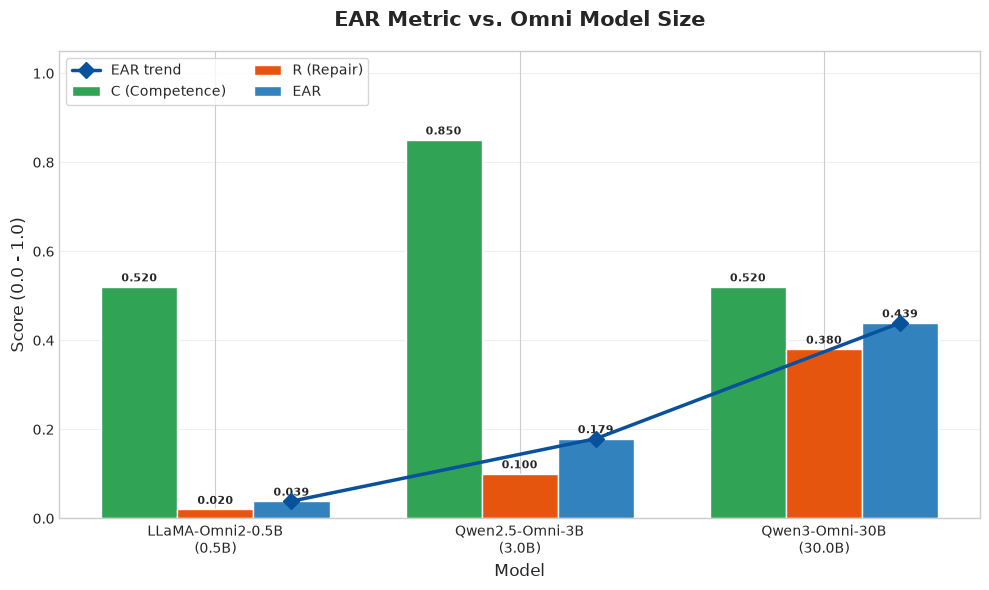

In [1]:
# Plot: C / R / EAR across the 3 evaluated omni models
import json
import numpy as np
import matplotlib.pyplot as plt

# (label, size in B, results jsonl path) -- ordered by size; edit paths if yours differ
MODELS = [
    ("LLaMA-Omni2-0.5B", 0.5, "ear_results_llama_omni2.jsonl"),
    ("Qwen2.5-Omni-3B",  3.0, "ear_results_qwen25.jsonl"),
    ("Qwen3-Omni-30B",  30.0, "ear_results_Qwen3-Omni-30B-A3B-Instruct.jsonl"),
]

def load_summary(path):
    """Return (C, R, EAR) from the last JSONL line that contains an EAR field."""
    summary = None
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if "EAR" in rec:                 # summary line (per-sample rows lack EAR)
                summary = rec
    if summary is None:
        raise ValueError(f"No summary line with C/R/EAR found in {path}")
    return float(summary["C"]), float(summary["R"]), float(summary["EAR"])

labels = [m[0] for m in MODELS]
sizes  = [m[1] for m in MODELS]
C, R, EAR = zip(*[load_summary(m[2]) for m in MODELS])

x = np.arange(len(MODELS))
width = 0.25

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

bars_c   = ax.bar(x - width, C,   width, label="C (Competence)", color="#31a354", edgecolor="white")
bars_r   = ax.bar(x,         R,   width, label="R (Repair)",     color="#e6550d", edgecolor="white")
bars_ear = ax.bar(x + width, EAR, width, label="EAR",            color="#3182bd", edgecolor="white")

# EAR trend line across model sizes
ax.plot(x + width, EAR, color="#08519c", marker="D", linestyle="-",
        linewidth=2.5, markersize=8, label="EAR trend", zorder=5)

# annotate every bar
for bars in (bars_c, bars_r, bars_ear):
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.3f}", (b.get_x() + b.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=8, fontweight="bold")

ax.set_title("EAR Metric vs. Omni Model Size", fontsize=15, pad=18, fontweight="bold")
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Score (0.0 - 1.0)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f"{lab}\n({s}B)" for lab, s in zip(labels, sizes)], fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper left", fontsize=10, frameon=True, ncol=2)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()